In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB.PDBExceptions import PDBConstructionWarning

PROJECT_ROOT = Path.cwd().resolve().parents[2]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from hamp_pred.utils.measure import calcPER
from hamp_pred.utils.tools import diffangle
from samcc.bundleClass import bundleClass
from samcc.helper_functions import gen_expected_crick_angles

warnings.filterwarnings(action='ignore', category=PDBConstructionWarning, module='Bio')
warnings.filterwarnings(action='ignore', category=UserWarning)

/home/users/sdunin/miniconda3/envs/hamppred/lib/python3.10/site-packages/paramiko/transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
def get_ref_crick(P, start_phi, REP_COUNT=5):
    REP_LEN, _ = calcPER(P)
    expected_angles = gen_expected_crick_angles(P, REP_LEN, start_phi)
    return np.tile(expected_angles, REP_COUNT)


def fix_cycle(tmp):
    return np.roll(tmp, -1)[::-1]

def circular_mean_axis1(data):
    rads = np.deg2rad(data)
    sin_mean = np.sin(rads).mean(axis=1)
    cos_mean = np.cos(rads).mean(axis=1)
    return np.rad2deg(np.arctan2(sin_mean, cos_mean))


In [3]:
def measure_helical_backbone(path_pdb_file, chain1_range, chain2_range, chain1=None, chain2=None):
    defdata = [
        [chain1_range, chain2_range, chain1_range, chain2_range],
        [chain1, chain1, chain2, chain2],
        [False, True, False, True],
        ['x', 'x', 'x', 'x']
    ]

    bundle = bundleClass()
    bundle.from_defdata(path_pdb_file, *defdata)
    bundle.calc_bundleaxis()
    bundle.calc_crick()
    bundle.calc_radius()
    bundle.calc_periodicity()
    bundle.calc_pitch_angle()
    bundle.calc_axialshift()

    cols = [
        'radius', 'crick', 'P', 'shift', 'crdev', 
        'positions_twister', 'p', 'positions_samcc', 'A'
    ]
    bundle_df = bundle.gendf(cols=cols)

    crick = bundle_df.crick.values.reshape(-1, 2)
    n_crick = circular_mean_axis1(crick[:, 0].reshape(-1, 2))
    c_crick = circular_mean_axis1(crick[:, 1].reshape(-1, 2))

    return bundle_df, n_crick, c_crick

In [4]:
def measure(pdb_file, a1_start, a2_start, segment_len, n_phi=None, c_phi=None, 
            n_P=None, c_P=None, chain1='A', chain2='B', use_reference=True):

    assert a1_start >= 0 and a2_start >= 0

    chain1_range = list(range(a1_start, a1_start + segment_len))
    chain2_range = list(range(a2_start - segment_len + 1, a2_start + 1))[::-1]

    bundle_df, n_crick, c_crick = measure_helical_backbone(
        pdb_file,
        chain1_range, chain2_range, chain1, chain2
    )

    n_crick = n_crick[1:-1]
    c_crick = c_crick[1:-1]

    rot = diffangle(-n_crick, c_crick) / 2

    n_crick_ref = get_ref_crick(n_P, n_phi)[:len(n_crick)]
    c_crick_ref = fix_cycle(get_ref_crick(c_P, c_phi))[:len(c_crick)]

    n_crick_diff = diffangle(n_crick, n_crick_ref)
    c_crick_diff = diffangle(c_crick, c_crick_ref)

    fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=200)

    ax.set_xticks(range(len(n_crick)))
    ax.set_xticklabels([str(i + 1) for i in range(len(n_crick))])

    ax.tick_params(axis='both', which='major', labelsize=5)
    ax.tick_params(axis='both', which='minor', labelsize=5)

    ax.plot(n_crick_diff, label="N helices", lw=2, c='salmon', ls='--')
    ax.plot(c_crick_diff, label="C helices", lw=2, c='lightblue', ls='--')
    ax.plot(rot, label="Relative", lw=2, c='k')

    ax.set_xlabel(r'Layer', size=10)
    ax.set_ylabel(r'Rotation [$\degree$]', size=10)
    ax.legend(prop={'size': 7})

    return bundle_df, rot.mean(), n_crick, c_crick

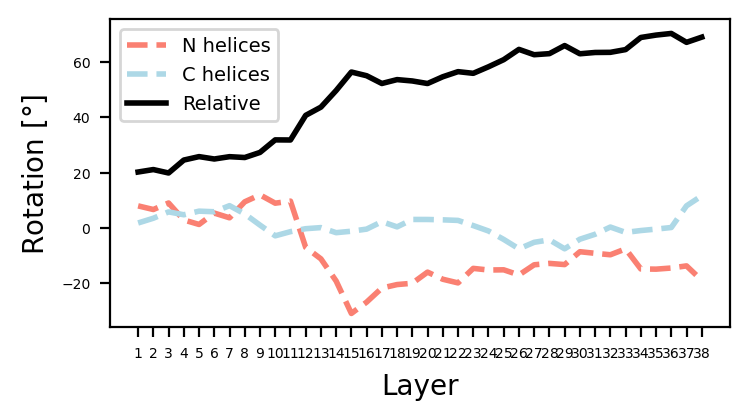

In [5]:
frame_file = '../example_pdb/frame_1.pdb'

# number of residues to remove from the HAMP side of the backbone
# use 16 to remove the kinked region (requires re-calculation of phi angles)
SHIFT = 0

# backbone N-terminal helix (continues into HAMP domain; has a kink in frame1)
a1_start_hb = 4 + SHIFT
# backbone C-terminal helix (co-axially stacked to HAMP)
a2_start_hb = 277 - SHIFT
segment_len_hb = 40 - SHIFT 

bundle_df, rot, n_crick, c_crick = measure(
    frame_file, 
    a1_start_hb, 
    a2_start_hb, 
    segment_len_hb, 
    n_phi=48.0, 
    c_phi=-98, 
    n_P=15/4, 
    c_P=11/3, 
    chain1='A', 
    chain2='B'
)

In [6]:
bundle_df.head(12)

res_name  res_number chain_name  chain_ap    radius       crick  \
layer chain                                                                   
0     0          LEU           4          A     False       NaN         NaN   
      1          THR         277          A      True       NaN         NaN   
      2          LEU           4          B     False       NaN         NaN   
      3          THR         277          B      True       NaN         NaN   
1     0          THR           5          A     False  8.504011   54.717576   
      1          PHE         276          A      True  7.908928  -96.146173   
      2          THR           5          B     False  8.215923   57.089584   
      3          PHE         276          B      True  8.311938  -96.451233   
2     0          PRO           6          A     False  8.102207  149.123265   
      1          VAL         275          A      True  8.109648  165.128799   
      2          PRO           6          B     False  7.683224  152.058576   
      3          VAL         275          B      True  8.442597  169.357219   

                    P     shift         p          A  
layer chain                                           
0     0           NaN       NaN       NaN        NaN  
      1           NaN       NaN       NaN        NaN  
      2           NaN       NaN       NaN        NaN  
      3           NaN       NaN       NaN        NaN  
1     0      3.787239 -0.894292  3.671710  24.915045  
      1      3.663322  0.458045  3.611362   8.997028  
      2      3.776092 -1.194649  3.638474  22.741438  
      3      3.694539  1.630896  3.735427  12.614120  
2     0      3.771106 -0.885851  3.637145  24.915045  
      1      3.651552  0.429397  3.644846   8.997028  
      2      3.767440 -0.982880  3.618029  22.741438  
      3      3.721708  1.439333  3.726639  12.614120

# setup phi for N terminal 

In [419]:
# 15/4
c = n_crick
c

array([  55.9036,  150.5909, -111.0443,  -21.1981,   73.1687,  173.2957,
        -92.4185,    9.3868,  107.9107, -159.1125,  -62.3666,   16.862 ,
        108.6852, -163.3566,  -79.1195,   20.987 ,  122.0978, -140.6427,
        -44.1655,   55.877 ,  149.2934, -116.041 ,  -14.7693,   80.638 ,
        176.7108,  -89.1585,   10.5358,  107.0386, -157.3884,  -56.7274,
         38.7028,  134.1712, -127.6911,  -38.9772,   56.9505,  153.3588,
       -109.8634,  -19.0951])

In [420]:
tmp=get_ref_crick(15/4, 0)[:15*2][::2]
print(len(tmp))
tmp

15


array([   0., -168.,   24., -144.,   48., -120.,   72.,  -96.,   96.,
        -72.,  120.,  -48.,  144.,  -24.,  168.])

In [421]:
print(c[0:5])
diff = tmp - c[0]
diff = (diff + 180) % 360 - 180
p=np.argmin(np.abs(diff))
tmp[p:p+5]

[  55.9036  150.5909 -111.0443  -21.1981   73.1687]


array([  48., -120.,   72.,  -96.,   96.])

In [422]:
np.set_printoptions(suppress=True, precision=4)
get_ref_crick(15/4, tmp[p])[:15]

array([  48.,  144., -120.,  -24.,   72.,  168.,  -96.,    0.,   96.,
       -168.,  -72.,   24.,  120., -144.,  -48.])

# setup phi C terminal 

In [423]:
# 11/3
c=c_crick
c

array([ -96.2987,  167.243 ,   71.3636,  -27.8653, -124.7325,  136.8692,
         40.8983,  -60.2975, -162.5171,   95.4074,   -1.2613,  -98.3693,
        163.8446,   63.8218,  -33.8311, -131.2522,  133.2718,   33.1987,
        -62.2883, -160.4803,  101.2055,    2.8188,  -97.2375,  162.6168,
         61.3702,  -40.2182, -136.036 ,  126.6779,   25.2381,  -69.4597,
       -165.8388,   98.5946,   -1.5337,  -99.0399,  163.298 ,   65.6976,
        -24.6194, -119.1629])

In [424]:
tmp=get_ref_crick(11/3, 0)[:11]
print(len(tmp))
tmp

11


array([   0.    ,   98.1818, -163.6364,  -65.4545,   32.7273,  130.9091,
       -130.9091,  -32.7273,   65.4545,  163.6364,  -98.1818])

In [425]:
print(c[0])
diff = tmp - c[0]
diff = (diff + 180) % 360 - 180
p=np.argmin(np.abs(diff))
tmp[p]

-96.29870265420361


-98.18181818181802

In [426]:
np.set_printoptions(suppress=True, precision=4)
r=get_ref_crick(11/3, tmp[p])
print(len(r))
r

55


array([ -98.1818,    0.    ,   98.1818, -163.6364,  -65.4545,   32.7273,
        130.9091, -130.9091,  -32.7273,   65.4545,  163.6364,  -98.1818,
          0.    ,   98.1818, -163.6364,  -65.4545,   32.7273,  130.9091,
       -130.9091,  -32.7273,   65.4545,  163.6364,  -98.1818,    0.    ,
         98.1818, -163.6364,  -65.4545,   32.7273,  130.9091, -130.9091,
        -32.7273,   65.4545,  163.6364,  -98.1818,    0.    ,   98.1818,
       -163.6364,  -65.4545,   32.7273,  130.9091, -130.9091,  -32.7273,
         65.4545,  163.6364,  -98.1818,    0.    ,   98.1818, -163.6364,
        -65.4545,   32.7273,  130.9091, -130.9091,  -32.7273,   65.4545,
        163.6364])

In [427]:
#fix_cycle(r)[::-1]